In [1]:
import numpy as np
import matplotlib.pyplot as plt

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *

from os.path import join
import json


In [3]:

use_real_machine = False


# set up device: Local Simulator
device = LocalSimulator()

print(f"Using {device.name}")

DATA_DIR = "state_prep"
EXPERIMENT_DIR = "ionq_experiments"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, EXPERIMENT_DIR)
check_and_make_dir(CURR_DIR)


Using StateVectorSimulator


In [94]:
N = 8
encoding = "antiferromagnetic"
if encoding == "unary" or encoding == "antiferromagnetic":
    n = N - 1
elif encoding == "one-hot":
    n = N


def state_prep(dimension, n, amplitudes, encoding):
    print(amplitudes)
    circuit = Circuit()

    for i in range(dimension):

        if encoding == "unary" or encoding == "antiferromagnetic":

            N = n + 1
            assert len(amplitudes) == N


            circuit.ry(i * n, 2 * np.arccos(amplitudes[0]))

            for k in np.arange(0, n-1):
                # Y rotation controlled on previous qubit

                # Basis change to Z
                circuit.rx(i * n + k+1, np.pi/2)
                # Controlled Z (note the parameter is slightly different from CZ)
                a = amplitudes[k+1] / np.linalg.norm(amplitudes[k+1:], ord=2)
                circuit.cphaseshift(i * n + k, i * n + k+1, 2 * np.arccos(a))
                circuit.rx(i * n + k+1, -np.pi/2)

            # Just map from unary to antiferromagnetic encoding
            if encoding == "antiferromagnetic":
                for k in range(n):
                    if k % 2 == 1:
                        circuit.x(i * n + k)
            

        elif encoding == "one-hot":
            N = n
            # Start from 1000...0
            circuit.x(i * n + 0)
            # Y rotation
            circuit.ry(i * n + 1, 2 * np.arccos(amplitudes[0]))
            circuit.cnot(1, 0)
            for k in np.arange(1, N-1):
                # Y rotation controlled on previous qubit
                # Basis change to Z
                circuit.rx(i * n + k+1, np.pi/2)
                # Controlled Z (note the parameter is slightly different from CZ)
                a = amplitudes[k] / np.linalg.norm(amplitudes[k:], ord=2)
                circuit.cphaseshift(i * n + k, i * n + k+1, 2 * np.arccos(a))
                circuit.rx(i * n + k+1, -np.pi/2)
                # CNOT
                
                circuit.cnot(i * n + k+1, i * n + k)
        else:
            raise ValueError("Encoding not supported")
    
    return circuit

def ghz_state_prep(n):
    assert n >= 1
    circuit = Circuit()
    # Prepare GHZ state
    circuit.h(0)
    for i in range(n-1):
        circuit.cnot(i, i+1)

    return circuit

def std_binary_state_prep(n, amplitudes):
    assert len(amplitudes) == 2 ** n
    
    circuit = Circuit()
    
    # Prepare the left half (using first n-1 qubits)
    # Prepare GHZ state
    circuit.add_circuit(ghz_state_prep(n))

    left_half = amplitudes[:2 ** (n - 1)] / np.linalg.norm(amplitudes[:2 ** (n - 1)])
    a = np.linalg.norm(left_half[:2 ** (n - 2)])
    circuit.ry(n-2, 2 * np.arccos(a))

    # Symmetric
    # Hadamard last qubit
    circuit.h(n-1)
    

    return circuit

def std_binary_state_prep_aux(n, amplitudes):

    circuit = Circuit()

    return circuit

In [95]:
n = 6
N = 2 ** 6
L, R = -4,4

xi_vals = np.linspace(L, R, N)
psi_0 = np.sqrt(2 / np.pi) / (xi_vals ** 2 + 1)
psi_0 /= np.linalg.norm(psi_0)

In [96]:
bitstrings = [np.binary_repr(j, n)[::-1] for j in range(2 ** n)]
print(bitstrings)

['000000', '100000', '010000', '110000', '001000', '101000', '011000', '111000', '000100', '100100', '010100', '110100', '001100', '101100', '011100', '111100', '000010', '100010', '010010', '110010', '001010', '101010', '011010', '111010', '000110', '100110', '010110', '110110', '001110', '101110', '011110', '111110', '000001', '100001', '010001', '110001', '001001', '101001', '011001', '111001', '000101', '100101', '010101', '110101', '001101', '101101', '011101', '111101', '000011', '100011', '010011', '110011', '001011', '101011', '011011', '111011', '000111', '100111', '010111', '110111', '001111', '101111', '011111', '111111']


In [97]:
circuit = std_binary_state_prep(n, psi_0)
circuit.amplitude(state=bitstrings)
print(circuit)


T  : |0|1|2|3|4|5|   6    |
                           
q0 : -H-C------------------
        |                  
q1 : ---X-C----------------
          |                
q2 : -----X-C--------------
            |              
q3 : -------X-C------------
              |            
q4 : ---------X-C-Ry(2.78)-
                |          
q5 : -----------X----------

T  : |0|1|2|3|4|5|   6    |

Additional result types: Amplitude(000000,100000,010000,110000,001000,101000,011000,111000,000100,100100,010100,110100,001100,101100,011100,111100,000010,100010,010010,110010,001010,101010,011010,111010,000110,100110,010110,110110,001110,101110,011110,111110,000001,100001,010001,110001,001001,101001,011001,111001,000101,100101,010101,110101,001101,101101,011101,111101,000011,100011,010011,110011,001011,101011,011011,111011,000111,100111,010111,110111,001111,101111,011111,111111)


In [98]:
task = device.run(circuit)
amplitudes_res = task.result().values[0]

In [99]:
psi_0

array([0.01677447, 0.0178226 , 0.01896965, 0.02022812, 0.02161248,
       0.02313953, 0.02482887, 0.02670341, 0.02879007, 0.03112057,
       0.03373243, 0.03667015, 0.03998672, 0.04374537, 0.04802173,
       0.05290628, 0.05850732, 0.06495404, 0.07239967, 0.08102399,
       0.09103387, 0.10265978, 0.11614408, 0.13171466, 0.14953416,
       0.16961248, 0.19167215, 0.21497133, 0.23812835, 0.25905792,
       0.27518212, 0.2840211 , 0.2840211 , 0.27518212, 0.25905792,
       0.23812835, 0.21497133, 0.19167215, 0.16961248, 0.14953416,
       0.13171466, 0.11614408, 0.10265978, 0.09103387, 0.08102399,
       0.07239967, 0.06495404, 0.05850732, 0.05290628, 0.04802173,
       0.04374537, 0.03998672, 0.03667015, 0.03373243, 0.03112057,
       0.02879007, 0.02670341, 0.02482887, 0.02313953, 0.02161248,
       0.02022812, 0.01896965, 0.0178226 , 0.01677447])

In [100]:
psi_0[:2 ** (n-1)]

array([0.01677447, 0.0178226 , 0.01896965, 0.02022812, 0.02161248,
       0.02313953, 0.02482887, 0.02670341, 0.02879007, 0.03112057,
       0.03373243, 0.03667015, 0.03998672, 0.04374537, 0.04802173,
       0.05290628, 0.05850732, 0.06495404, 0.07239967, 0.08102399,
       0.09103387, 0.10265978, 0.11614408, 0.13171466, 0.14953416,
       0.16961248, 0.19167215, 0.21497133, 0.23812835, 0.25905792,
       0.27518212, 0.2840211 ])

In [101]:
np.linalg.norm(psi_0[:2 ** (n-2)])

0.12883254736962976

In [102]:
amplitudes_res

{'000000': (0.12883254736962982+0j),
 '100000': 0j,
 '010000': 0j,
 '110000': 0j,
 '001000': 0j,
 '101000': 0j,
 '011000': 0j,
 '111000': 0j,
 '000100': 0j,
 '100100': 0j,
 '010100': 0j,
 '110100': 0j,
 '001100': 0j,
 '101100': 0j,
 '011100': 0j,
 '111100': 0j,
 '000010': (0.6952712957819069+0j),
 '100010': 0j,
 '010010': 0j,
 '110010': 0j,
 '001010': 0j,
 '101010': 0j,
 '011010': 0j,
 '111010': 0j,
 '000110': 0j,
 '100110': 0j,
 '010110': 0j,
 '110110': 0j,
 '001110': 0j,
 '101110': 0j,
 '011110': 0j,
 '111110': 0j,
 '000001': 0j,
 '100001': 0j,
 '010001': 0j,
 '110001': 0j,
 '001001': 0j,
 '101001': 0j,
 '011001': 0j,
 '111001': 0j,
 '000101': 0j,
 '100101': 0j,
 '010101': 0j,
 '110101': 0j,
 '001101': 0j,
 '101101': 0j,
 '011101': 0j,
 '111101': (-0.6952712957819069+0j),
 '000011': 0j,
 '100011': 0j,
 '010011': 0j,
 '110011': 0j,
 '001011': 0j,
 '101011': 0j,
 '011011': 0j,
 '111011': 0j,
 '000111': 0j,
 '100111': 0j,
 '010111': 0j,
 '110111': 0j,
 '001111': 0j,
 '101111': 0j,
 '011

In [ ]:
circuit = std_binary_state_prep(n, psi_0)

In [9]:
psi_0

array([-0.01136194, -0.01178969, -0.0122509 , -0.01274966, -0.01329076,
       -0.01387983, -0.01452353, -0.01522984, -0.01600836, -0.01687076,
       -0.01783138, -0.01890799, -0.02012296, -0.02150479, -0.0230904 ,
       -0.02492844, -0.02708442, -0.02964862, -0.03274913, -0.03657385,
       -0.04141006, -0.04772016, -0.05629907, -0.06863859, -0.08790556,
       -0.12221017, -0.20042468, -0.55673521,  0.71580242,  0.21785291,
        0.12847736,  0.09110213,  0.07057207,  0.0575933 ,  0.04864677,
        0.04210602,  0.03711568,  0.03318289,  0.03000369,  0.02738042,
        0.02517898,  0.0233052 ,  0.02169098,  0.0202859 ,  0.01905178,
        0.0179592 ,  0.01698514,  0.01611131,  0.01532299,  0.01460821,
        0.01395715,  0.01336165,  0.01281488,  0.0123111 ,  0.01184543,
        0.01141371,  0.01101234,  0.01063825,  0.01028874,  0.00996147,
        0.00965437,  0.00936564,  0.00909368,  0.00883707])

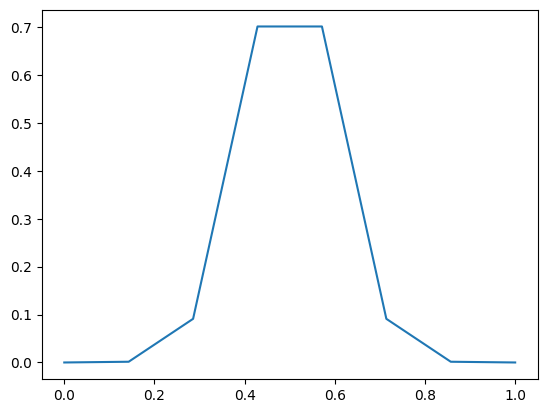

In [31]:
x = np.linspace(0, 1, N)

mu = 0.5
sigma = 0.1

u_0 = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
# u_0 = 1-np.linspace(0,1, N)
u_0 /= np.linalg.norm(u_0)
plt.plot(x, u_0)
plt.show()

In [32]:
circuit = state_prep(1, n, u_0, encoding)

[3.37254328e-06 1.53781233e-03 9.11032516e-02 7.01211689e-01
 7.01211689e-01 9.11032516e-02 1.53781233e-03 3.37254328e-06]


In [33]:
print(circuit)

T  : |   0    |     1     |    2    |     3     |    4    |     5     |    6    |     7     |    8    |     9     |   10    |    11     |   12    |
                                                                                                                                                   
q0 : -Ry(3.14)-C-----------------------------------------------------------------------------------------------------------------------------------
               |                                                                                                                                   
q1 : -Rx(1.57)-PHASE(3.14)-Rx(-1.57)-C-----------X-------------------------------------------------------------------------------------------------
                                     |                                                                                                             
q2 : -Rx(1.57)-----------------------PHASE(2.96)-Rx(-1.57)-C----------------------------------------------------

In [34]:
num_shots = 5000

task = device.run(circuit, shots=num_shots)
result = task.result()
occurrences = get_occurrences(N, result.measurements, num_shots=num_shots, dimension=1, encoding=encoding)
dist = np.zeros_like(occurrences)
if np.sum(occurrences) > 0:
    dist = occurrences / np.sum(occurrences)


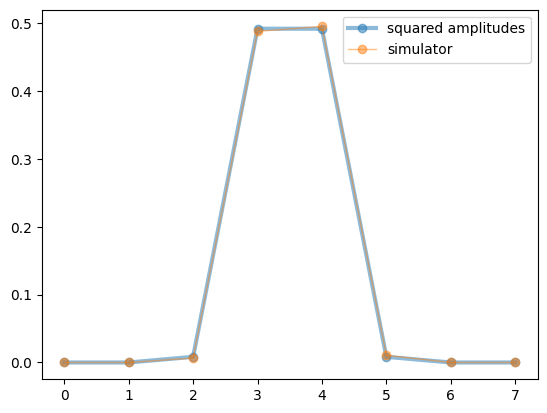

In [35]:
plt.plot(range(N), u_0 ** 2, '-o', label="squared amplitudes", alpha=0.5, linewidth=3)
plt.plot(range(N), dist, '-o', label="simulator", alpha=0.5, linewidth=1)
plt.legend()
plt.show()